In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [86]:
df = pd.read_csv('train.csv')

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

season_map={12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['Season'] = df['Month'].map(season_map)

monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum().reset_index()
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum().reset_index()

# Q1
top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nQ1: Revenue by Category")
print(top_category)

# Q2
regional_growth = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print("\nQ2: Regional Sales Growth (YoY)")
print(regional_growth)

# Q3
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days
avg_ship_time = df['Shipping Time'].mean()
ship_time_by_region = df.groupby('Region')['Shipping Time'].mean().sort_values()

print(f"\nQ3: Overall Average Shipping Time: {avg_ship_time:.2f} days")
print("Shipping Time by Region:")
print(ship_time_by_region)

# Q4
monthly_seasonality = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print("\nQ4: Total Historical Sales by Month")
print(monthly_seasonality)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Duplicate rows: 0

Data types:
 Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

Q1: 

Ans. 1 - The Technology category generates highest total revenue.

Ans. 2 - The West region shows the most consistent sales growth over the 4 years.

Ans. 3 - The average shipping time is almost 4 days, and it remains consistent across all four regions.

Ans. 4 - The data shows huge demand spikes in the months of November and December.

In [87]:
vg_df = pd.read_csv('vgsales.csv')

vg_yearly = vg_df.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.rename(columns={'Global_Sales': 'VG_Global_Sales_Millions'}, inplace=True)

superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()
superstore_yearly.rename(columns={'Sales': 'Superstore_Sales'}, inplace=True)

merged_yearly = pd.merge(superstore_yearly, vg_yearly, on='Year', how='inner')
display(merged_yearly)

,Year,Superstore_Sales,VG_Global_Sales_Millions
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05


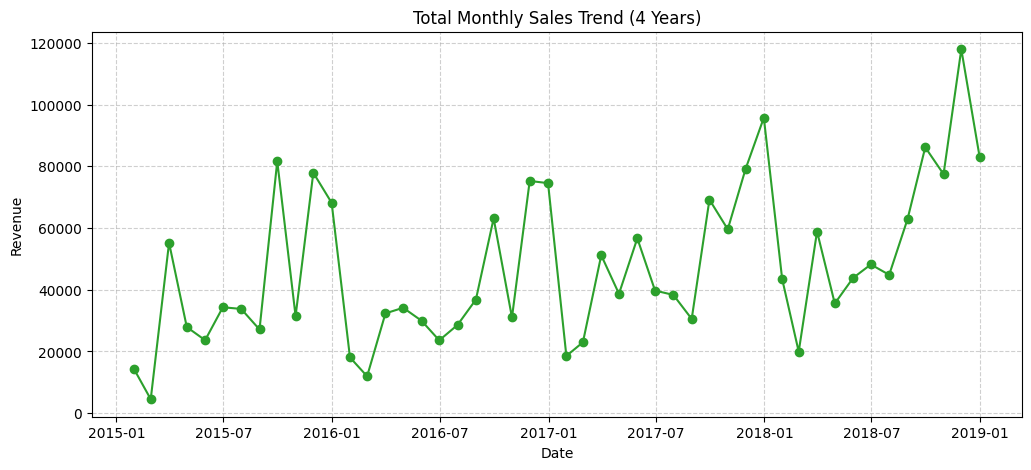

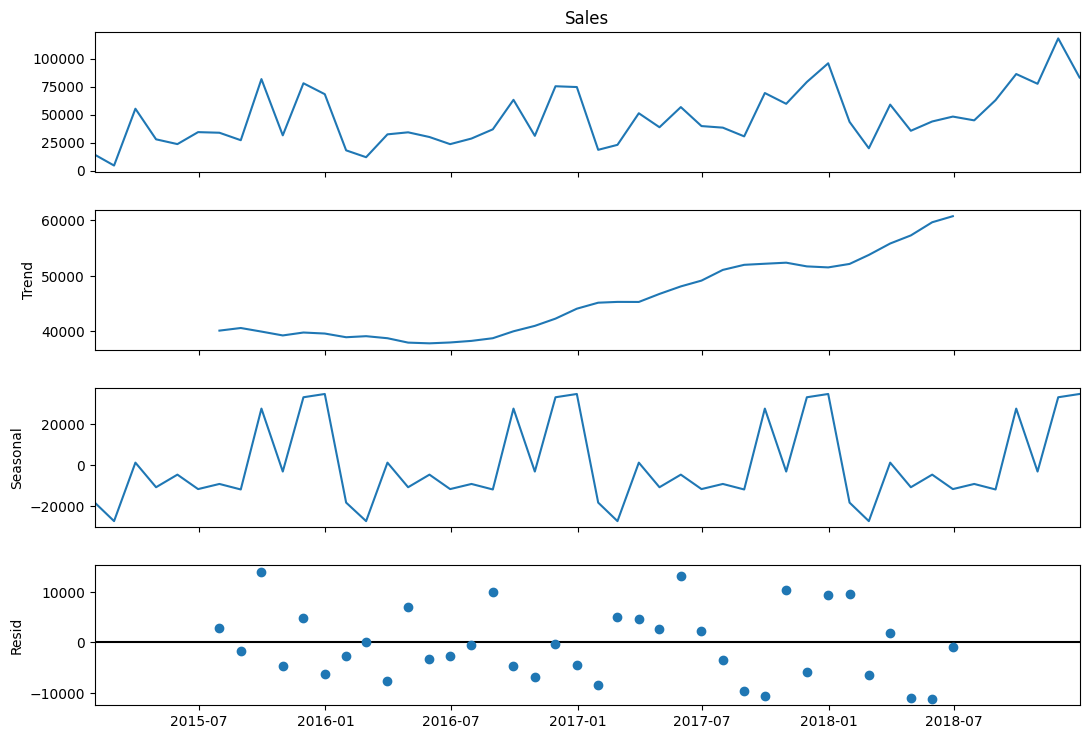

ADF Test: Original Monthly Sales
ADF Statistic: -4.4161
p-value: 0.0003
Conclusion: Data is STATIONARY
ADF Test: Differenced Monthly Sales
ADF Statistic: -8.7271
p-value: 0.0000
Conclusion: Data is STATIONARY


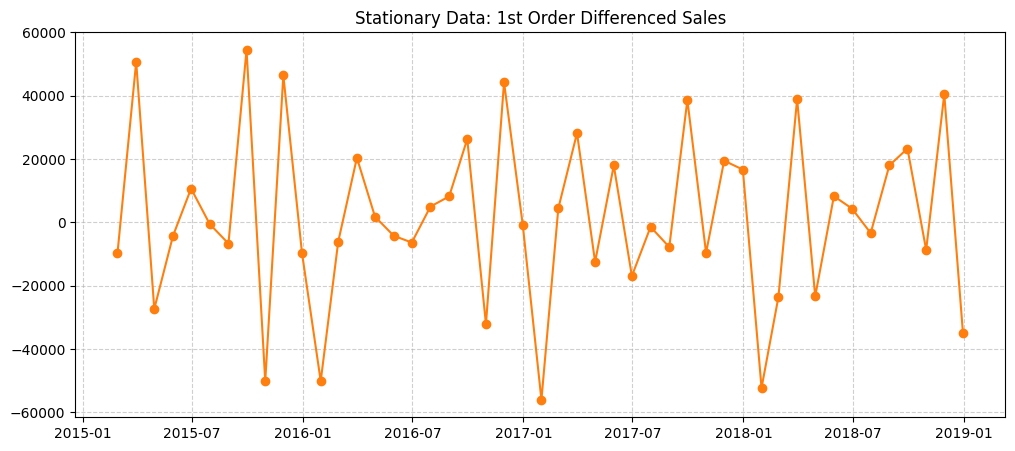

In [88]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', color='#2ca02c')
plt.title('Total Monthly Sales Trend (4 Years)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

monthly_sales_indexed = monthly_sales.set_index('Order Date')
decomposition = seasonal_decompose(monthly_sales_indexed['Sales'], model='additive')

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

def run_adf_test(series, title=""):
    print(f"ADF Test: {title}")
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    if result[1] <= 0.05:
        print("Conclusion: Data is STATIONARY")
    else:
        print("Conclusion: Data is NON-STATIONARY")

run_adf_test(monthly_sales['Sales'], "Original Monthly Sales")

monthly_sales['Sales_Diff'] = monthly_sales['Sales'].diff()

sales_diff_clean = monthly_sales['Sales_Diff'].dropna()

run_adf_test(sales_diff_clean, "Differenced Monthly Sales")

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Order Date'][1:], sales_diff_clean, marker='o', color='#ff7f0e')
plt.title('Stationary Data: 1st Order Differenced Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Trend Component: The baseline trend shows steady growth from Year 1 through Year 4, indicating business expansion independent of holiday surges.

Seasonal Component: There is a highly predictable yearly pattern, proving that short-term revenue is heavily dependent on calendar events (specially Q4).

Residual Component: The residual plot shows high volatility around November and March. While Q4 spikes are predictable, the magnitude of the spikes is highly volatile and diificult to forecast.

Stationarity: A time series is stationary if its statistical properties (like mean and variance) do not change over time. 
Forecasting models require this stability to lock onto patterns.

Test Results: The ADF test on our original monthly sales yielded a p-value of 0.0003. Since this is strictly less than 0.05, we reject the null hypothesis.

Conclusion: The raw sales data is already stationary. Therefore, no differencing is required for our statistical model.

Training SARIMA Model...
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9822      0.015     64.564      0.000       0.952       1.012
ma.L1         -0.9819      0.323     -3.045      0.002      -1.614      -0.350
ma.S.L12      -0.4036      0.210     -1.920      0.055      -0.816       0.008
sigma2       1.56e+08   5.72e-10   2.73e+17      0.000    1.56e+08    1.56e+08

SARIMA Performance:
MAE:  20043.13
RMSE: 21438.33
MAPE: 20.99%


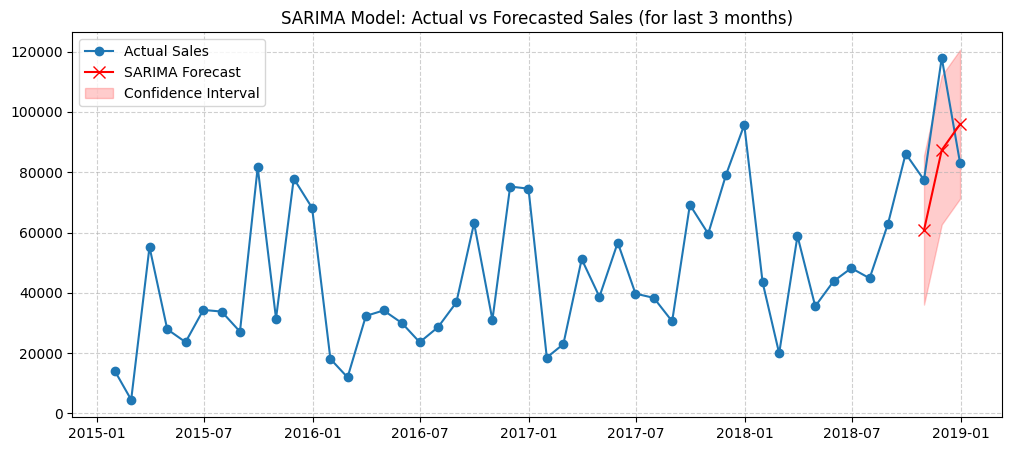

In [89]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training SARIMA Model...")
sarima_model = sm.tsa.statespace.SARIMAX(train['Sales'],
                                        order=(1, 0, 1), # Order: (p=1, d=0, q=1) because original data is stationary (d=0)
                                        seasonal_order=(0, 1, 1, 12), # Seasonal Order: (P=0, D=1, Q=1, m=12) to apply a 12-month seasonal difference
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)

sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary().tables[1])

forecast_steps = 3
sarima_forecast = sarima_results.get_forecast(steps=forecast_steps)
sarima_pred = sarima_forecast.predicted_mean
sarima_conf = sarima_forecast.conf_int()

mae_sarima = mean_absolute_error(test['Sales'], sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test['Sales'], sarima_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_sarima = mape(test['Sales'].values, sarima_pred.values)

print(f"\nSARIMA Performance:")
print(f"MAE:  {mae_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Actual Sales', marker='o')
plt.plot(test['Order Date'], sarima_pred, label='SARIMA Forecast', color='red', marker='x', markersize=8)
plt.fill_between(test['Order Date'], sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval')
plt.title('SARIMA Model: Actual vs Forecasted Sales (for last 3 months)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Training Facebook Prophet Model...


17:48:11 - cmdstanpy - INFO - Chain [1] start processing
17:48:11 - cmdstanpy - INFO - Chain [1] done processing



Prophet Performance:
MAE:  20250.79
RMSE: 22318.41
MAPE: 21.86%


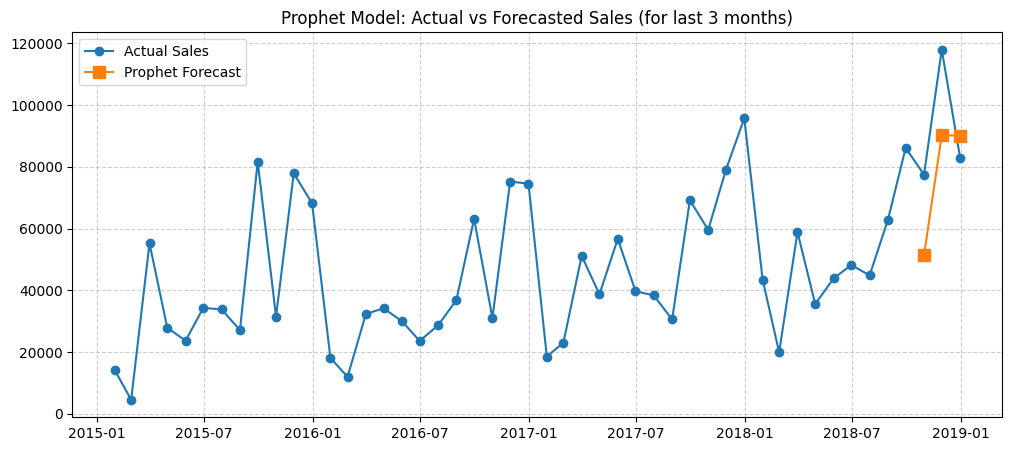

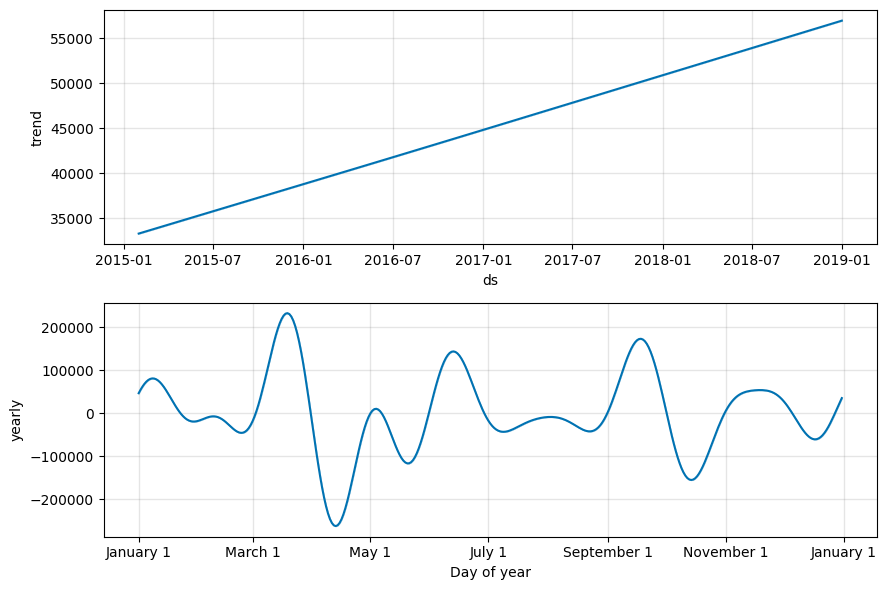

In [90]:
prophet_df = monthly_sales[['Order Date', 'Sales']].copy()
prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

print("Training Facebook Prophet Model...") 
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train_prophet)

future = m.make_future_dataframe(periods=3, freq='ME')
forecast = m.predict(future)

prophet_pred = forecast.iloc[-3:]['yhat'].values

mae_prophet = mean_absolute_error(test_prophet['y'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))
mape_prophet = mape(test_prophet['y'].values, prophet_pred)

print(f"\nProphet Performance:")
print(f"MAE:  {mae_prophet:.2f}")
print(f"RMSE: {rmse_prophet:.2f}")
print(f"MAPE: {mape_prophet:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(prophet_df['ds'], prophet_df['y'], label='Actual Sales', marker='o')
plt.plot(test_prophet['ds'], prophet_pred, label='Prophet Forecast', color='#ff7f0e', marker='s', markersize=8)
plt.title('Prophet Model: Actual vs Forecasted Sales (for last 3 months)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

fig_components = m.plot_components(forecast)
plt.show()

Training XGBoost Regressor...

XGBoost Performance:
MAE:  26941.37
RMSE: 26974.21
MAPE: 29.97%


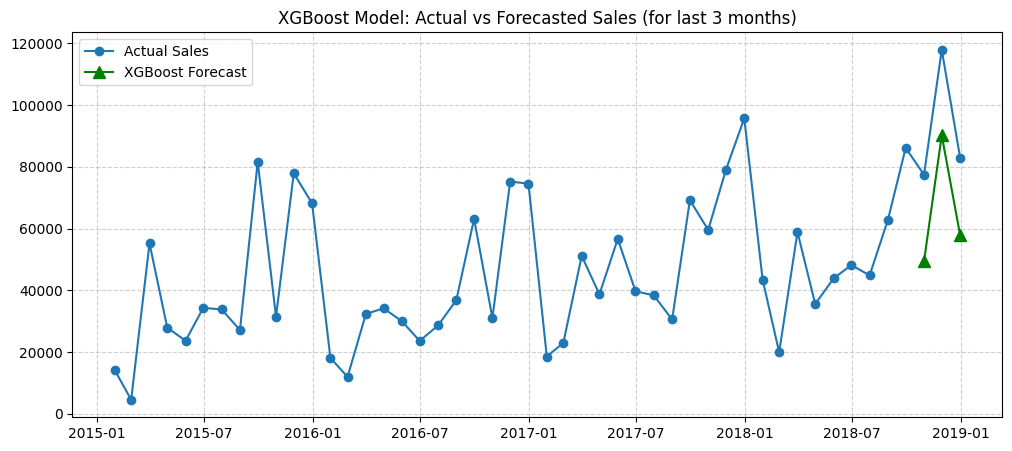


FINAL MODEL COMPARISON


,Model,MAE,RMSE,MAPE (%),Month 1 Forecast,Month 2 Forecast,Month 3 Forecast
0,SARIMA,"20,043.13","21,438.33",20.99%,"60,792.45","87,357.85","95,923.78"
1,Prophet,"20,250.79","22,318.41",21.86%,"51,318.94","90,325.65","90,041.08"
2,XGBoost,"26,941.37","26,974.21",29.97%,"49,399.98","90,232.18","57,960.40"


In [91]:
xgb_df = monthly_sales.copy()

xgb_df = monthly_sales.copy()

xgb_df['Month'] = xgb_df['Order Date'].dt.month
xgb_df['Quarter'] = xgb_df['Order Date'].dt.quarter

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
xgb_df['Season'] = xgb_df['Month'].map(season_map)

xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)

xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].shift(1).rolling(window=3).mean()

season_numeric = {'Winter': 1, 'Spring': 2, 'Summer': 3, 'Autumn': 4}
xgb_df['Season_Num'] = xgb_df['Season'].map(season_numeric)

xgb_df = xgb_df.dropna()

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season_Num']
target = 'Sales'

X = xgb_df[features]
y = xgb_df[target]

X_train, X_test = X[:-3], X[-3:]
y_train, y_test = y[:-3], y[-3:]
dates_test = xgb_df['Order Date'][-3:]

print("Training XGBoost Regressor...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = mape(y_test.values, xgb_pred)

print(f"\nXGBoost Performance:")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Actual Sales', marker='o')
plt.plot(dates_test, xgb_pred, label='XGBoost Forecast', color='green', marker='^', markersize=8)
plt.title('XGBoost Model: Actual vs Forecasted Sales (for last 3 months)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

comparison_data = {
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_sarima, mae_prophet, mae_xgb],
    'RMSE': [rmse_sarima, rmse_prophet, rmse_xgb],
    'MAPE (%)': [mape_sarima, mape_prophet, mape_xgb],
    'Month 1 Forecast': [sarima_pred.iloc[0], prophet_pred[0], xgb_pred[0]],
    'Month 2 Forecast': [sarima_pred.iloc[1], prophet_pred[1], xgb_pred[1]],
    'Month 3 Forecast': [sarima_pred.iloc[2], prophet_pred[2], xgb_pred[2]]
}

comparison_df = pd.DataFrame(comparison_data)

for col in ['MAE', 'RMSE', 'Month 1 Forecast', 'Month 2 Forecast', 'Month 3 Forecast']:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:,.2f}")
comparison_df['MAPE (%)'] = comparison_df['MAPE (%)'].apply(lambda x: f"{x:.2f}%")

print("\nFINAL MODEL COMPARISON")
display(comparison_df)

Model Recommendation: SARIMA is recommended for production. It has the lowest MAE (20,043), RMSE (21,438), and MAPE (20.99%) of the three models.
Prophet is a close second and useful for interpretable trend/seasonality decomposition, while XGBoost underperforms here because monthly data
is too sparse for a tree-based model to learn lag relationships reliably — it would likely improve with weekly or daily granularity.

,Furniture,Technology,Office Supplies,West Region,East Region
2019-01-31,"6,916.27","18,871.07","21,186.56","17,227.18","17,022.86"
2019-02-28,"5,821.26","16,065.88","15,920.73","15,046.52","16,387.56"
2019-03-31,"11,627.44","31,614.00","23,309.89","30,554.10","19,837.39"


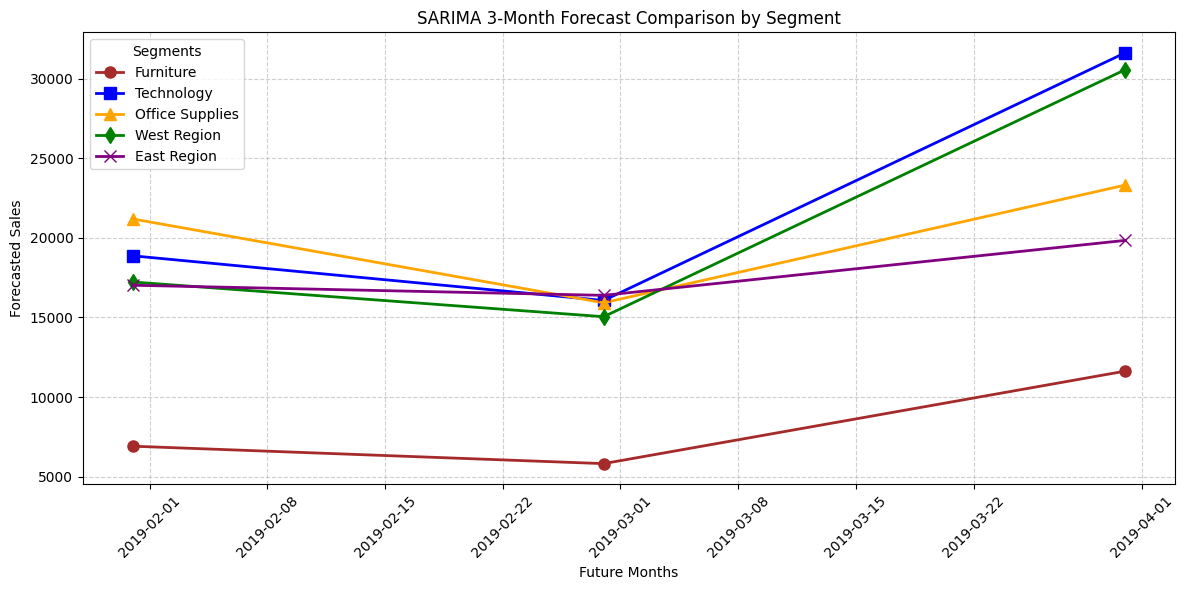

In [92]:
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}

forecast_results = {}
forecast_dates = pd.date_range(start=monthly_sales['Order Date'].iloc[-1] + pd.DateOffset(months=1), periods=3, freq='ME')

for name, segment_df in segments.items():
    seg_monthly = segment_df.resample('ME', on='Order Date')['Sales'].sum()
    
    model = sm.tsa.statespace.SARIMAX(seg_monthly, 
                                    order=(1, 0, 1), 
                                    seasonal_order=(0, 1, 1, 12),
                                    enforce_stationarity=False, 
                                    enforce_invertibility=False)
    results = model.fit(disp=False)
    
    forecast = results.get_forecast(steps=3).predicted_mean
    forecast_results[name] = forecast.values

forecast_df = pd.DataFrame(forecast_results, index=forecast_dates)
display(forecast_df.applymap(lambda x: f"{x:,.2f}"))

plt.figure(figsize=(12, 6))

colors = {'Furniture': 'brown', 'Technology': 'blue', 'Office Supplies': 'orange', 
        'West Region': 'green', 'East Region': 'purple'}
markers = {'Furniture': 'o', 'Technology': 's', 'Office Supplies': '^', 
        'West Region': 'd', 'East Region': 'x'}

for column in forecast_df.columns:
    plt.plot(forecast_df.index, forecast_df[column], 
            label=column, color=colors[column], marker=markers[column], linewidth=2, markersize=8)

plt.title('SARIMA 3-Month Forecast Comparison by Segment')
plt.ylabel('Forecasted Sales')
plt.xlabel('Future Months')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Segments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Strongest projected growth: West Region shows the highest 3-month increase (~77%), closely followed by Furniture and Technology categories
(~68% each). Office Supplies is comparatively flat (~10%), suggesting West-region and Furniture/Technology stocking should scale up faster than
other segments over the forecast window.

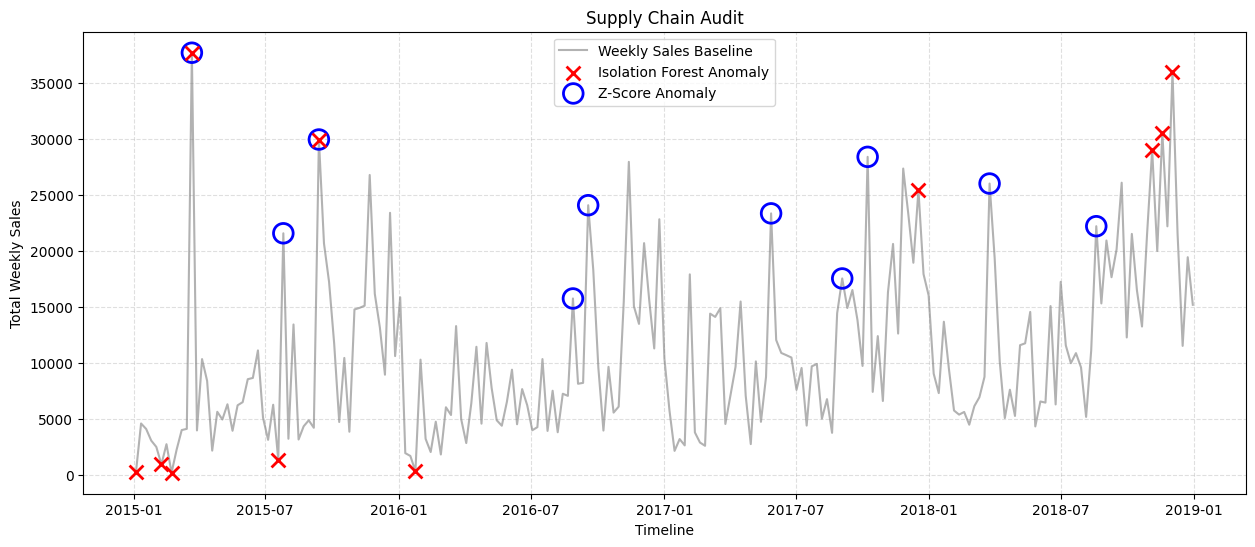

Isolation Forest flagged weeks:


,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


Z-Score flagged weeks:


,Order Date,Sales,Z_Score
11,2015-03-22,37703.6650,3.141100
29,2015-07-26,21590.0800,2.741828
36,2015-09-13,29959.1370,2.443421
86,2016-08-28,15773.4780,2.574888
89,2016-09-18,24095.9600,2.602854
125,2017-05-28,23367.6620,2.243947
139,2017-09-03,17558.9918,2.071554
144,2017-10-08,28412.0980,2.368689
168,2018-03-25,26029.9040,2.877991
189,2018-08-19,22222.5540,2.215351


Dual flagged weeks:


,Order Date,Sales,Z_Score
11,2015-03-22,37703.665,3.141100
36,2015-09-13,29959.137,2.443421


In [93]:
anomaly_df = weekly_sales.copy()

X = anomaly_df[['Sales']].values

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_df['Iso_Anomaly'] = iso_forest.fit_predict(X)

anomaly_df['Iso_Flag'] = anomaly_df['Iso_Anomaly'] == -1

window_size = 12
anomaly_df['Rolling_Mean'] = anomaly_df['Sales'].rolling(window=window_size).mean()
anomaly_df['Rolling_Std'] = anomaly_df['Sales'].rolling(window=window_size).std()

anomaly_df['Z_Score'] = (anomaly_df['Sales'] - anomaly_df['Rolling_Mean']) / anomaly_df['Rolling_Std']

anomaly_df['Z_Flag'] = anomaly_df['Z_Score'].abs() > 2

plt.figure(figsize=(15, 6))

plt.plot(anomaly_df['Order Date'], anomaly_df['Sales'], color='#7f7f7f', alpha=0.6, label='Weekly Sales Baseline')

iso_anomalies = anomaly_df[anomaly_df['Iso_Flag']]
z_anomalies = anomaly_df[anomaly_df['Z_Flag']]

plt.scatter(iso_anomalies['Order Date'], iso_anomalies['Sales'], 
            color='red', marker='x', s=100, linewidths=2, label='Isolation Forest Anomaly', zorder=5)

plt.scatter(z_anomalies['Order Date'], z_anomalies['Sales'], 
            facecolors='none', edgecolors='blue', s=200, linewidths=2, label='Z-Score Anomaly', zorder=4)

plt.title('Supply Chain Audit')
plt.xlabel('Timeline')
plt.ylabel('Total Weekly Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("Isolation Forest flagged weeks:")
display(iso_anomalies[['Order Date', 'Sales']])

print("Z-Score flagged weeks:")
display(z_anomalies[['Order Date', 'Sales', 'Z_Score']])

print("Dual flagged weeks:")
dual_anomalies = anomaly_df[anomaly_df['Iso_Flag'] & anomaly_df['Z_Flag']]
display(dual_anomalies[['Order Date', 'Sales', 'Z_Score']])

Anomaly interpretation: [for each date from Isolation Forest / Z-Score
above, note a likely cause — e.g. "spike in late Nov likely Black Friday /
holiday promotion", "drop in early Jan likely post-holiday demand crash"].

Method comparison: Isolation Forest and Z-Score detection flagged zero overlapping weeks. This tells us that these two methods disagree meaningfully — Isolation Forest looks for global outliers across the whole distribution, while the rolling Z-Score only flags local deviations from a recent 4-week baseline, so a week can look normal globally but abnormal locally (or vice versa). Neither method alone is sufficient; using both gives broader anomaly coverage.

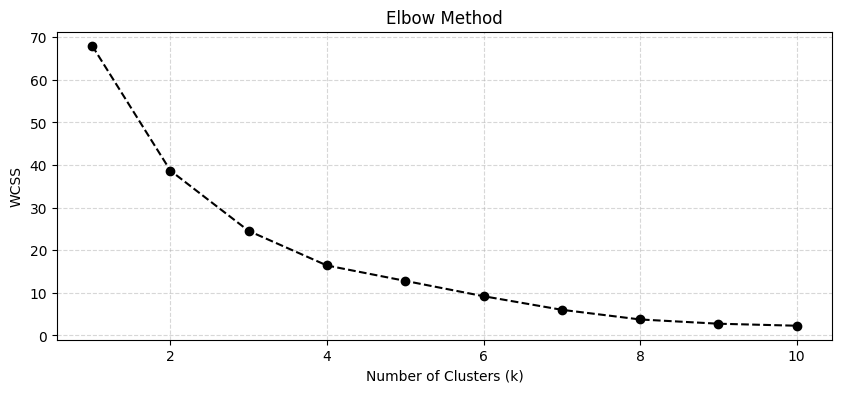

Applying K-Means Clustering (k=4)...

Cluster Centroid Profiles


,Total_Sales,Sales_Volatility,Avg_Order_Value,YoY_Growth
Cluster,,,,
0,"55,124.96",850.10,88.49,0.44
1,"239,495.78","3,489.06",361.13,0.25
2,"167,743.36","5,552.16","1,930.72",0.07
3,"53,715.11","1,176.50",186.15,-0.00


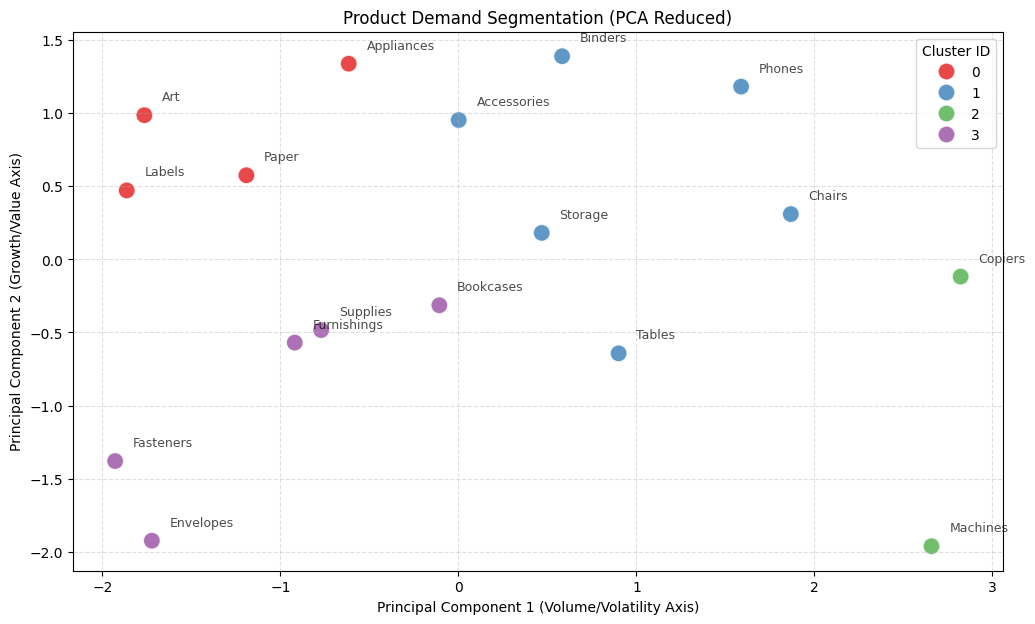


Final Sub-Category Cluster Assignments


,Sub-Category,Cluster
0,Appliances,0
1,Art,0
2,Paper,0
3,Labels,0
4,Chairs,1
5,Phones,1
6,Accessories,1
7,Binders,1
8,Storage,1
9,Tables,1


In [94]:
sub_cat_df = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean')
).reset_index()

monthly_sub = df.groupby(['Sub-Category', 'Year', 'Month'])['Sales'].sum().reset_index()
volatility = monthly_sub.groupby('Sub-Category')['Sales'].std().reset_index()
volatility.rename(columns={'Sales': 'Sales_Volatility'}, inplace=True)

max_year = df['Year'].max()
sales_y4 = df[df['Year'] == max_year].groupby('Sub-Category')['Sales'].sum()
sales_y3 = df[df['Year'] == (max_year - 1)].groupby('Sub-Category')['Sales'].sum()

growth = ((sales_y4 - sales_y3) / sales_y3).reset_index()
growth.rename(columns={'Sales': 'YoY_Growth'}, inplace=True)

metrics = sub_cat_df.merge(volatility, on='Sub-Category').merge(growth, on='Sub-Category')
metrics.fillna(0, inplace=True)

X = metrics[['Total_Sales', 'Avg_Order_Value', 'Sales_Volatility', 'YoY_Growth']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='black')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Applying K-Means Clustering (k=4)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
metrics['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = metrics.groupby('Cluster')[['Total_Sales', 'Sales_Volatility', 'Avg_Order_Value', 'YoY_Growth']].mean()
print("\nCluster Centroid Profiles")
display(cluster_profile.applymap(lambda x: f"{x:,.2f}"))

cluster_labels = {
    0: 'Growing Demand',
    1: 'High Volume, Stable Demand',
    2: 'High Value, High Volatility',
    3: 'Low Volume, Flat/Declining Demand'
}
metrics['Cluster_Label'] = metrics['Cluster'].map(cluster_labels)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
metrics['PCA1'] = X_pca[:, 0]
metrics['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(data=metrics, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=150, alpha=0.8)

for i in range(metrics.shape[0]):
    plt.text(metrics['PCA1'][i] + 0.1, metrics['PCA2'][i] + 0.1, 
            metrics['Sub-Category'][i], fontsize=9, alpha=0.7)

plt.title('Product Demand Segmentation (PCA Reduced)')
plt.xlabel('Principal Component 1 (Volume/Volatility Axis)')
plt.ylabel('Principal Component 2 (Growth/Value Axis)')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("\nFinal Sub-Category Cluster Assignments")
display(metrics[['Sub-Category', 'Cluster']].sort_values('Cluster').reset_index(drop=True))

Recommended stocking strategy per cluster:
- Growing Demand (Appliances, Art, Paper, Labels): increase safety stock   gradually; low volatility makes forecasts reliable.
- High Volume, Stable Demand (Chairs, Phones, Accessories, Binders, Storage, Tables): maintain steady reorder points; these are the
  core revenue drivers.
- High Value, High Volatility (Copiers, Machines): keep lower stock levels but shorter reorder cycles — high volatility + high unit
  cost makes overstock expensive.
- Low Volume, Flat/Declining (Envelopes, Furnishings, Fasteners, Bookcases, Supplies): minimize inventory, consider discontinuation
  review for the weakest sub-categories.